Preprocessing: Spike cleaning and peak-to-peak thresholding available. \
Plotting: Spectrogram, morlet transform, spatial data plotting available.

In [ ]:
!git clone https://github.com/mserhat1/NMA_Project.git
import sys
sys.path.append('/content/NMA_Project')

In [ ]:
%cd NMA_Project
!pip install -r requirements.txt

Extract data

In [ ]:
from functions.data import get_datafile

sbj = 10
session = 3

nwbfile = get_datafile(sbj=sbj, session=session)

NOTE: If you want to just look at spatial data, skip to the "plotting spatial data" cell.

Extract neural data

In [ ]:
from functions.data import extract_neural_data

# specify parameters
channel = 7
pre_time = 2
post_time = 1
behavior = ['Talk', 'Talk, TV', 'Computer/phone', 'TV', 'Eat, Talk', 'Eat, TV', 'Other activity']

ecog_data = extract_neural_data(nwbfile, channel=channel, pre_time=pre_time, post_time=post_time, behavior=behavior)

Apply further preprocessing

In [10]:
from functions.preprocessing import spike_cleaning, ptp_thresholding

filtered_data = ptp_thresholding(ecog_data, threshold_uv=250)

Kept 70 out of 156 epochs after amplitude filtering.


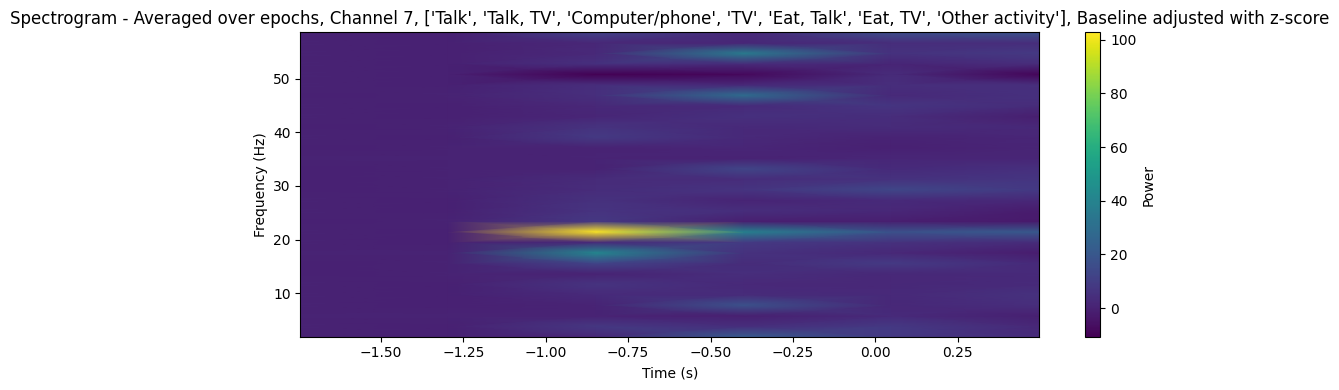

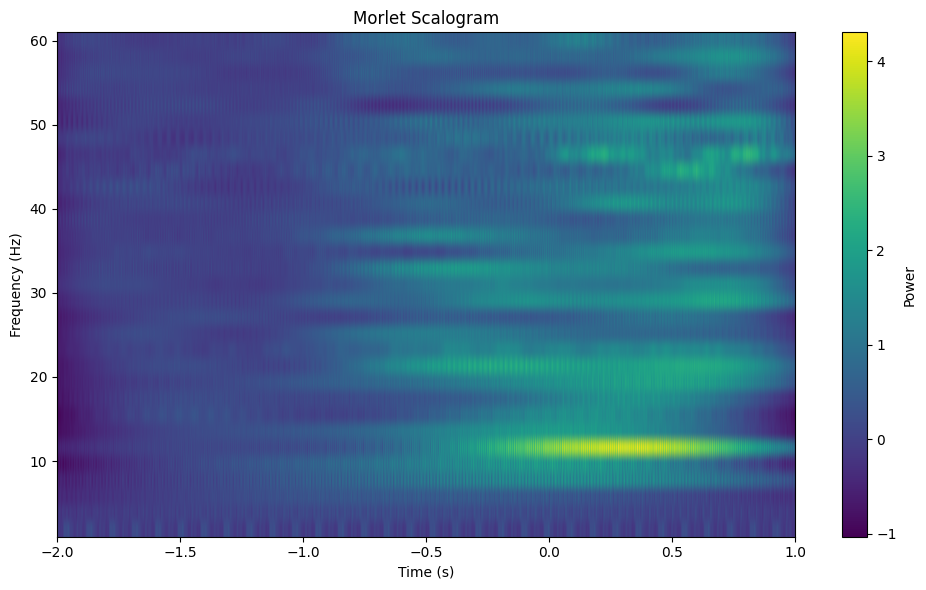

In [19]:
from functions.plotting import plot_spectrogram, plot_morlet


# computes spectrogram for each time epoch around the event, then averages across epochs
# specify parameters
plot_spectrogram(filtered_data, lower_freq=1, upper_freq=60, nperseg=256)

# complex morlet wavelet transform, baseline corrected with z-score (per epoch),
# I will include the option to apply baseline correction after averaging the
# transforms as well.
# specify parameters
plot_morlet(filtered_data, lower_freq=1, upper_freq=60, B=4, C=10)

Plotting spatial data

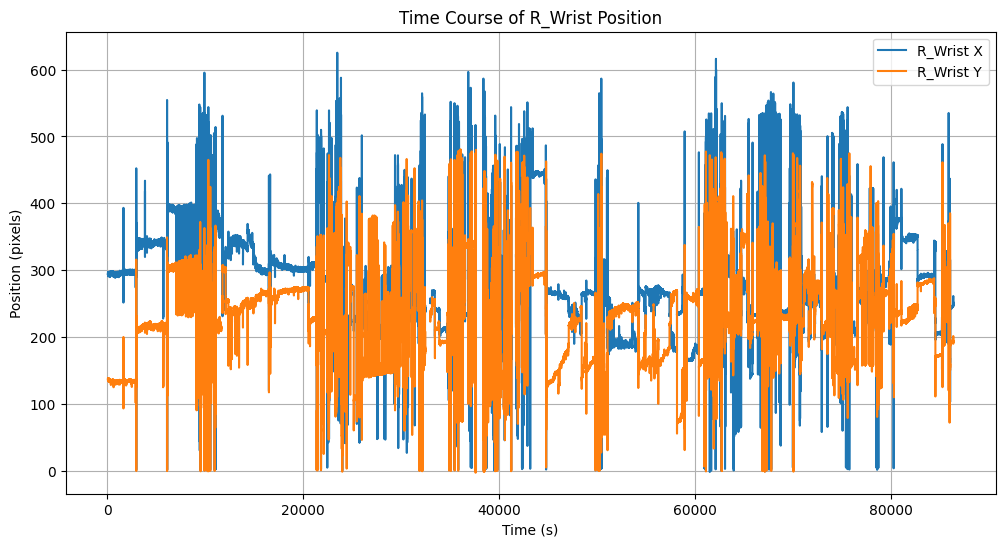

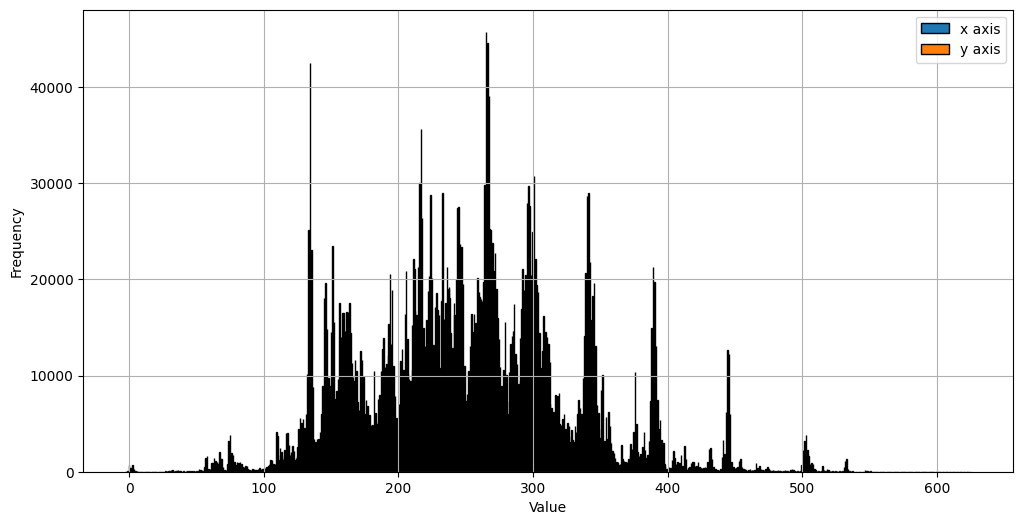

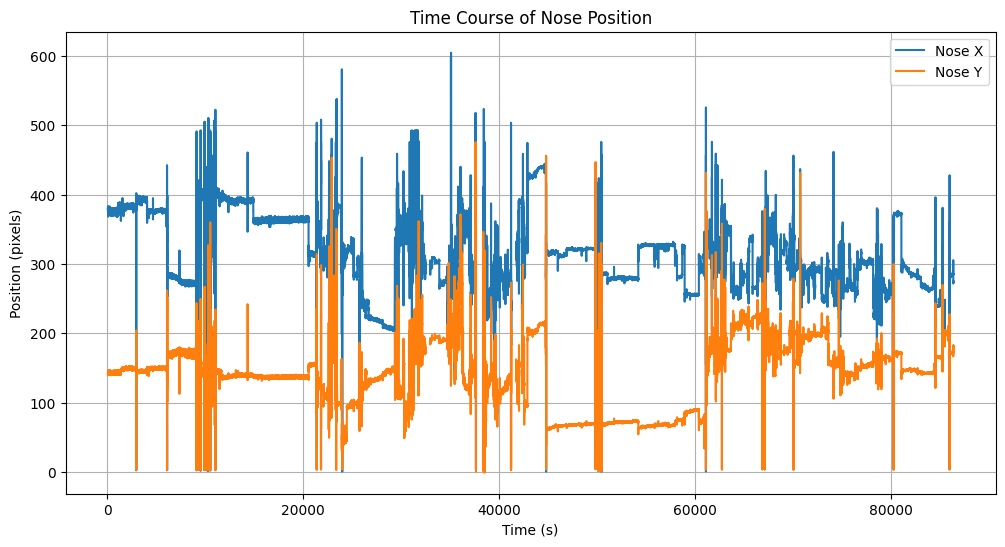

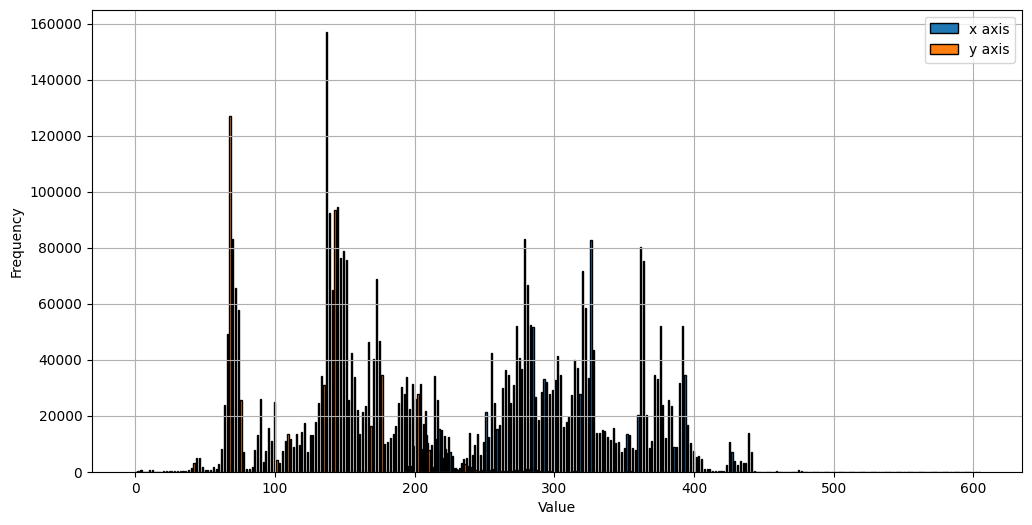

In [6]:
from functions.data import extract_spatial_data
from functions.plotting import plot_spatial_data

keypoints = ['R_Wrist', 'Nose']
time_window='all'

# If time_window is 'all', it shows you the entire data.
# If you want a specific time window, uncomment the line below and adjust the interval.
#time_window = (78000, 82000)

# maybe add an option to restrict/select time windows
# possible to plot a trajectory of the keypoint according to this data?
spatial_data = extract_spatial_data(nwbfile)
plot_spatial_data(spatial_data, keypoints, time_window=time_window, plot_histogram=True)